In [2]:
import pandas as pd
import numpy as np

In [6]:
data = pd.read_excel('validated_data_merged_tax (4).xlsx', index_col = 0)
# columnss to be dropped
cols = ['new sn', 'sn', 'new','article_list', 'journal_name', 'publisher', 'year', 'title',
       'journal_is_oa', 'is_oa', 'oa_status', 'verification required',
       'verified_by', 'verification_date', 'has_mistake_in_data',
       'has_mistake_in_matadata', 'entry_status', 'comment', 'accept/reject',
       'Unnamed: 44', 'IdList', 
        'zeta_potential (mV)', 
        'pH during synthesis', 
        'Concentration of precursor (mM)', 'hydrodynamic diameter', 'Precursor of NP', 
        'Clade', 'Class', 'Family']
# data = data.drop(cols, axis=1)

In [ ]:
def fill_na_mode(df, col_name=str):
  df[col_name] = df[col_name].fillna(df[col_name].mode()[0])
  return df

def fill_na_mean(df, col_name=str):
  df[col_name] = df[col_name].fillna(df[col_name].mean())
  return df

df = data.copy()
df['np_size_avg (nm)'] = df['np_size_avg (nm)'].astype('float64')
fill_mode = ['time_set (hours)', 'Solvent for extract', 'shape']
fill_mean = [ 'Duration preparing extract, min', 'Temperature for extract, C']

for col_name in fill_mode:
  fill_na_mode(df, col_name)

for col_name in fill_mean:
  fill_na_mean(df, col_name)


In [ ]:
def filter_cat(df, col, perc):
    df = df.filter(pl.col(col)
        .is_in(df.group_by(col).count()
        .filter(pl.col("count") >= df.height * perc).select(col).to_series()))
    return df 
def my_preprocessing(df):
    filtered_df1 = df.filter(pl.col("MIC_NP (µg/mL)") < 5000) 
    filtered_df1 = filtered_df1.filter(pl.col("MIC_NP (µg/mL)") > 0)
    filtered_df1 = filtered_df1.filter(pl.col('np_size_min (nm)') <150)
    filtered_df1 = filtered_df1.filter(pl.col('np_size_avg (nm)') <200)
    filtered_df1 = filtered_df1.filter(pl.col('np_size_max (nm)') <300)
    filtered_df1 = filtered_df1.filter(pl.col('Duration preparing extract, min') < 10000)
    filtered_df1 = filtered_df1.filter(pl.col('min_Incub_period, h') <100)
    filtered_df1 = filtered_df1.filter(pl.col('avg_Incub_period, h') <150)
    filtered_df1 = filtered_df1.filter(pl.col('max_Incub_period, h') <200)
    filtered_df1 = filtered_df1.filter(pl.col('time_set (hours)') < 60)
    filtered_df1 = filtered_df1.filter(pl.col('growth_temp, C ') > 25)
    
    filtered_df1 = filtered_df1.filter(pl.col('growth_temp, C ') > 25)
    # percentile_99 = df.select(pl.col("").quantile(0.99)).item()
    # # Filter out rows where 'values' > 99th percentile (top 1%)
    # filtered_df = df.filter(pl.col("values") <= percentile_99)
    # print(filtered_df1.group_by("np").count().sort('count'))
    
    print(f'Before preprocessing: {df.shape} \nAfter preprocessing numerical columns:{filtered_df1.shape}')
    
    filtered_df1 = filter_cat(filtered_df1, 'shape', 0.005)
    filtered_df1 = filter_cat(filtered_df1, 'np', 0.005)
    filtered_df1 = filter_cat(filtered_df1, 'method', 0.005)
    # filtered_df1 = filter_cat(filtered_df1, 'Bacteria', 0.005)
    filtered_df1 = filtered_df1.with_columns(pl.col('MIC_NP (µg/mL)').log().alias('MIC_NP (µg/mL)')) 
    filtered_df1 = filtered_df1.filter(pl.col("MIC_NP (µg/mL)") > -4)
    # print(filtered_df1.group_by("Bacteria").count().sort('count'))
    print(f'After preprocessing categorical columns too {filtered_df1.shape}')
    return filtered_df1


In [4]:
def fill_size_missing_values(df, avg_col='np_size_avg (nm)', max_col='np_size_max (nm)', min_col='np_size_min (nm)'):

    result_df = df.copy()

    avg_mask = result_df[avg_col].isna()
    result_df.loc[avg_mask, avg_col] = (
        result_df.loc[avg_mask, max_col] + 
        result_df.loc[avg_mask, min_col]
    ) / 2

    max_mask = result_df[max_col].isna()
    result_df.loc[max_mask, max_col] = result_df.loc[max_mask, avg_col]
    
    min_mask = result_df[min_col].isna()
    result_df.loc[min_mask, min_col] = result_df.loc[min_mask, avg_col]
    
    return result_df

In [115]:
filled_df = fill_size_missing_values(df)

In [118]:
MIC_method = ['MIC', 'MBC', 'MBEC', 'MBIC', 'MIc', 'MFC', 'MMC']

In [136]:
MIC_df = filled_df[filled_df['method'].isin(MIC_method)]
MIC_df = MIC_df.drop(['concentration for ZOI (µg/ml)', 'zoi_np (mm)'], axis = 1)

In [ ]:
# Example usage with your dataframe
def analyze_dataframe(df, numerical_threshold=3):
    """
    Complete analysis of a dataframe
    """
    print("🔍 Starting Data Analysis\n")
    
    # Get column types
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    
    print(f"Numerical columns: {numerical_cols}")
    print(f"Categorical columns: {categorical_cols}\n")
    
    # Outlier analysis for numerical columns
    if numerical_cols:
        print("📊 Outlier Analysis (IQR Method)")
        iqr_outliers = detect_outliers_iqr(df, numerical_cols)
        print_outlier_report(iqr_outliers, "IQR")
        
        print("\n📊 Outlier Analysis (Z-score Method)")
        zscore_outliers = detect_outliers_zscore(df, numerical_cols, numerical_threshold)
        print_outlier_report(zscore_outliers, "Z-score")
        
        print("\n📈 Visualizing Outliers")
        visualize_outliers(df, numerical_cols)
    
    # Categorical distribution analysis
    if categorical_cols:
        print("\n🎯 Categorical Distribution Analysis")
        cat_distribution = analyze_categorical_distribution(df, categorical_cols)
        print_categorical_report(cat_distribution)
        
        print("\n📊 Visualizing Categorical Distributions")
        visualize_categorical_distribution(df, categorical_cols)
        
        print("\n🥧 Pie Charts for Suitable Columns")
        create_pie_charts(df, categorical_cols)
    
    print("\n✅ Analysis complete!")



🔍 Starting Data Analysis

Numerical columns: ['Unnamed: 0', 'coating', 'mdr', 'MIC_NP (µg/mL)', 'np_size_min (nm)', 'np_size_max (nm)', 'np_size_avg (nm)', 'time_set (hours)', 'Temperature for extract, C', 'Duration preparing extract, min', 'min_Incub_period, h', 'avg_Incub_period, h', 'max_Incub_period, h', 'growth_temp, C ', 'biosafety_level']
Categorical columns: ['np', 'bacteria', 'strain', 'np_synthesis', 'method', 'shape', 'Solvent for extract', 'reference', 'doi', 'Bacteria', 'Strain', 'Superkingdom', 'Kingdom', 'Phylum', 'Order', 'Genus', 'Species', 'bac_type', 'gram', 'common_environment', 'prim_specific_habitat', 'sec_habitat']

📊 Outlier Analysis (IQR Method)
=== Outlier Detection Report (IQR Method) ===

Column: Unnamed: 0
  Outlier count: 0
  Outlier percentage: 0.00%
  Lower bound: -1763.50
  Upper bound: 4846.50
  Outlier values: []
--------------------------------------------------
Column: coating
  Outlier count: 433
  Outlier percentage: 20.64%
  Lower bound: 0.00
  U

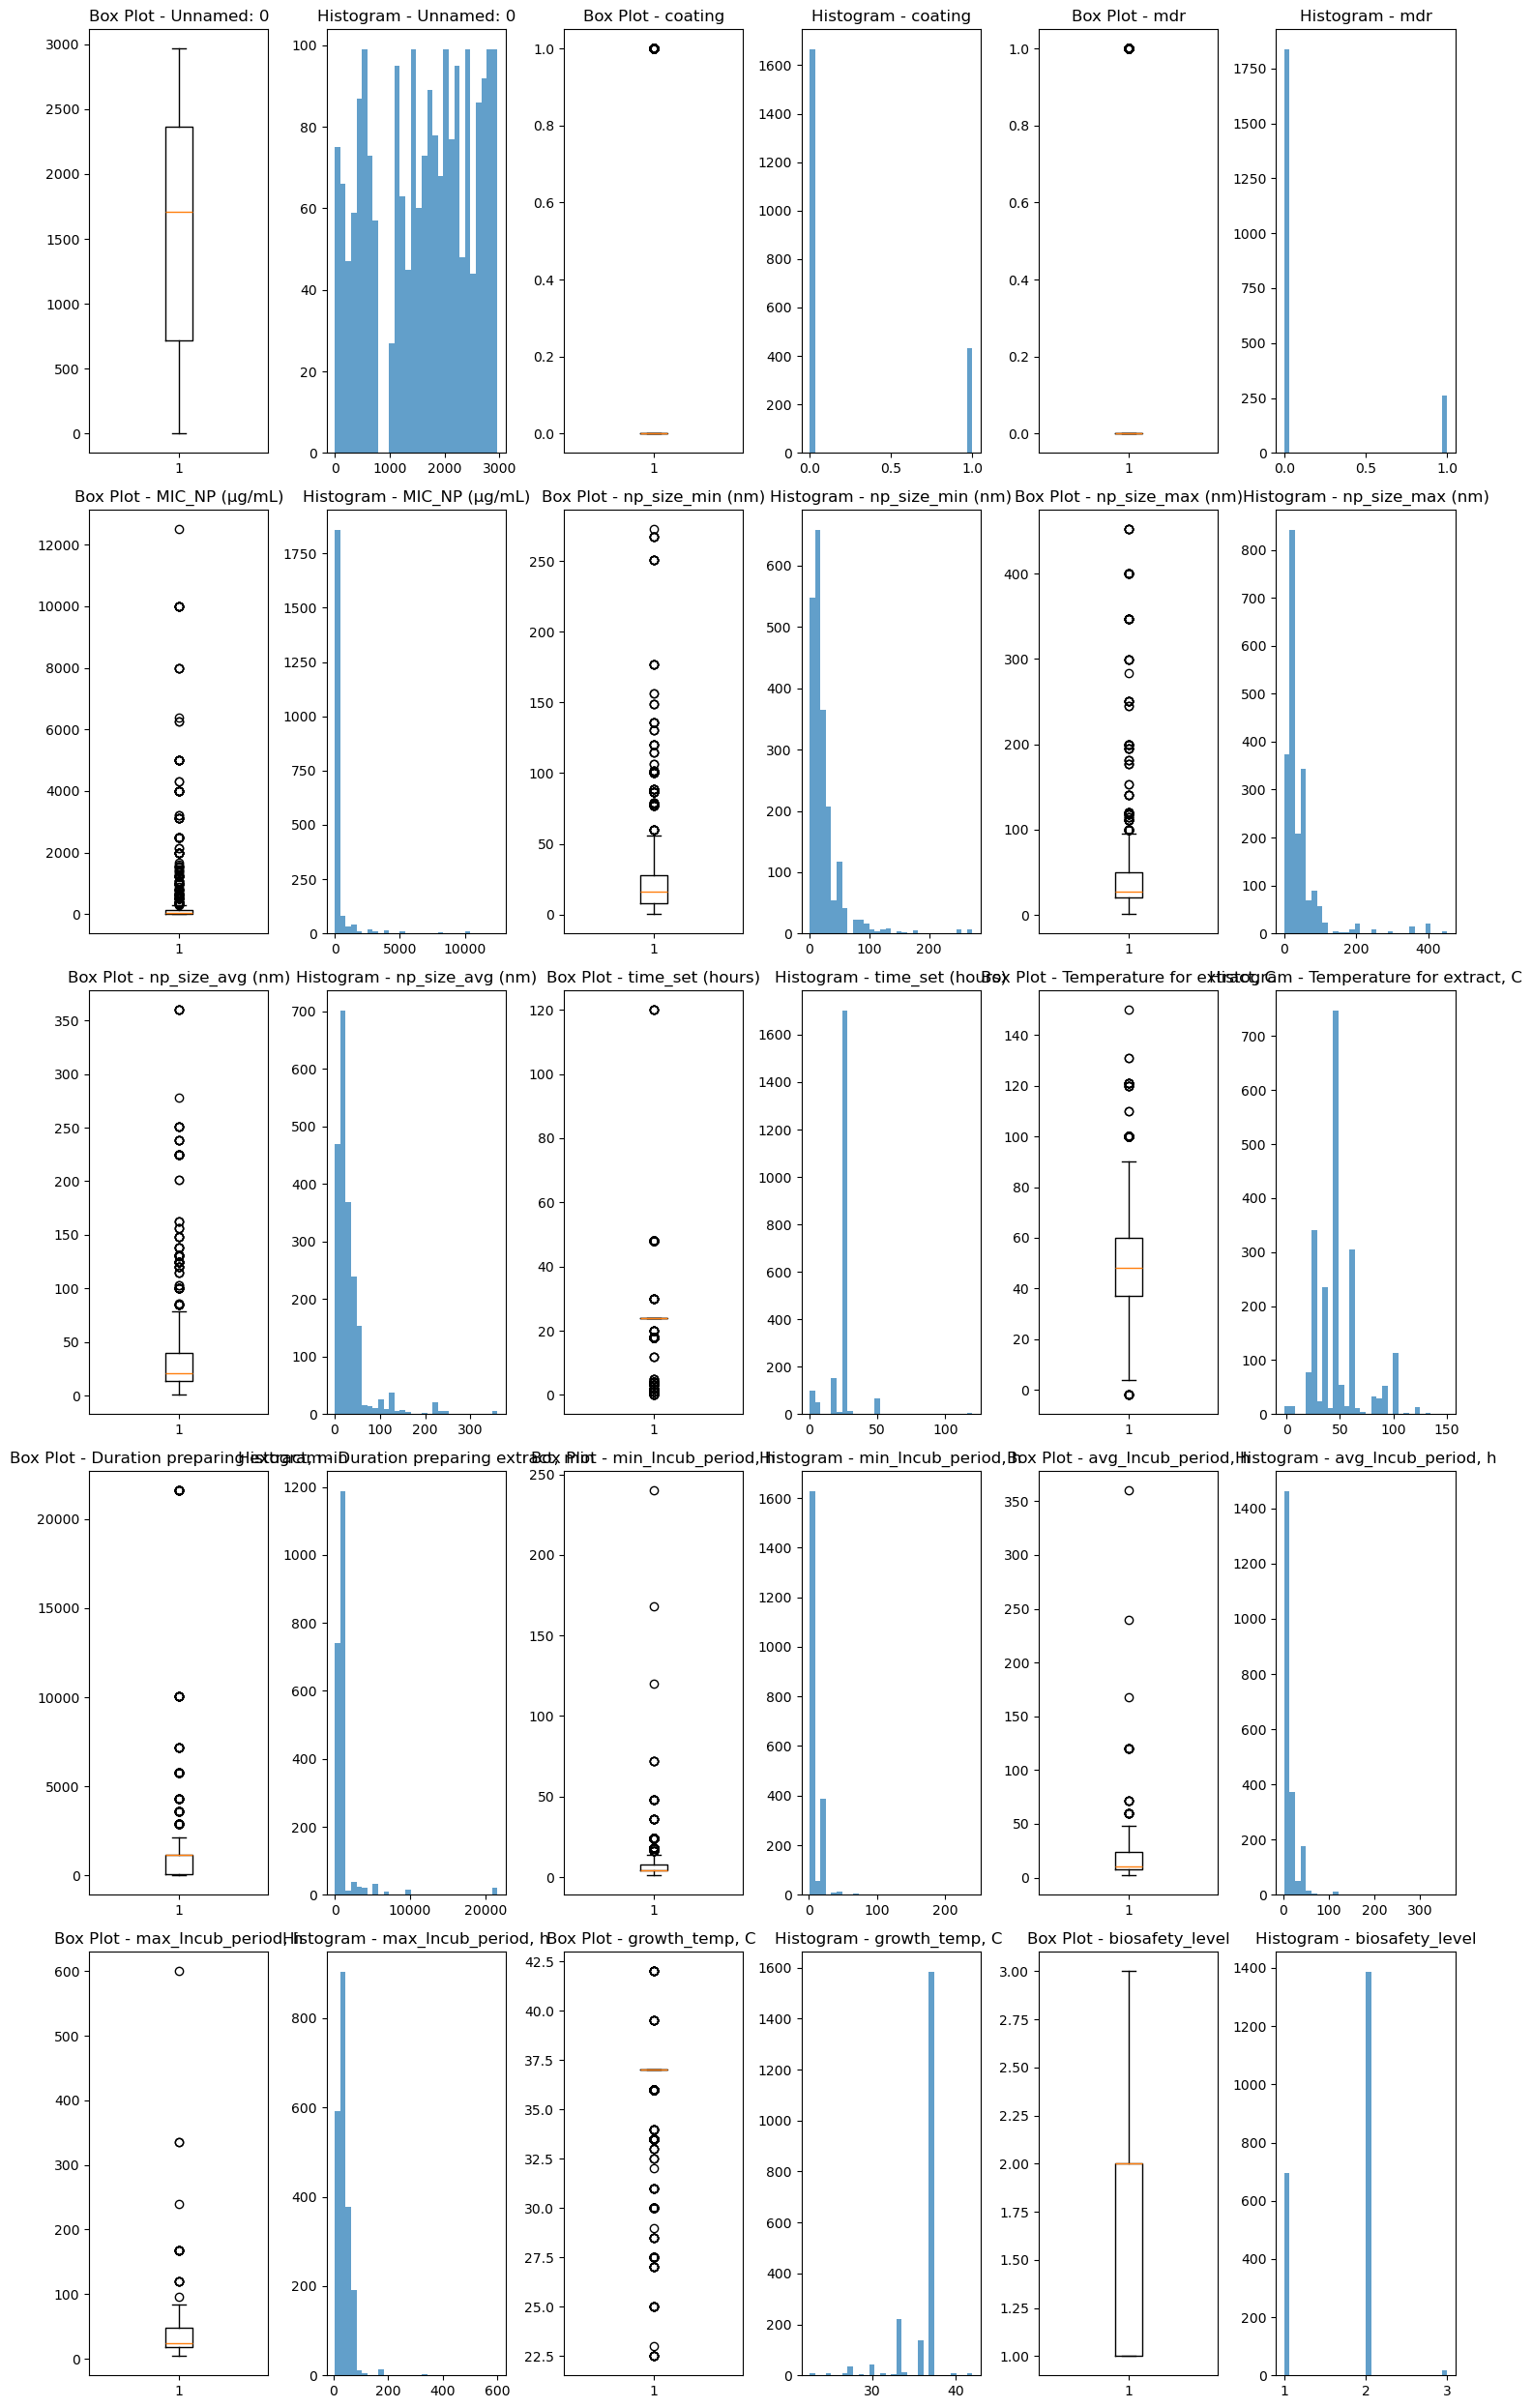


🎯 Categorical Distribution Analysis
=== Categorical Distribution Report ===

Column: np
  Unique values: 15
  Missing values: 0 (0.00%)
  Top values:
    Ag: 1709 (81.46%)
    ZnO: 212 (10.10%)
    Au: 51 (2.43%)
    CuO: 34 (1.62%)
    Cu: 16 (0.76%)
    Al2O3: 16 (0.76%)
    TiO2: 14 (0.67%)
    CeO2: 10 (0.48%)
    Pd: 10 (0.48%)
    Bi2O3: 6 (0.29%)
--------------------------------------------------
Column: bacteria
  Unique values: 102
  Missing values: 0 (0.00%)
  Top values:
    Escherichia coli: 465 (22.16%)
    Staphylococcus aureus: 445 (21.21%)
    Pseudomonas aeruginosa: 232 (11.06%)
    Klebsiella pneumoniae: 142 (6.77%)
    Bacillus subtilis: 88 (4.19%)
    Enterococcus faecalis: 57 (2.72%)
    Staphylococcus epidermidis: 52 (2.48%)
    Acinetobacter baumannii: 51 (2.43%)
    Candida albicans: 51 (2.43%)
    Salmonella enterica: 45 (2.14%)
--------------------------------------------------
Column: strain
  Unique values: 276
  Missing values: 767 (36.56%)
  Top values:
 

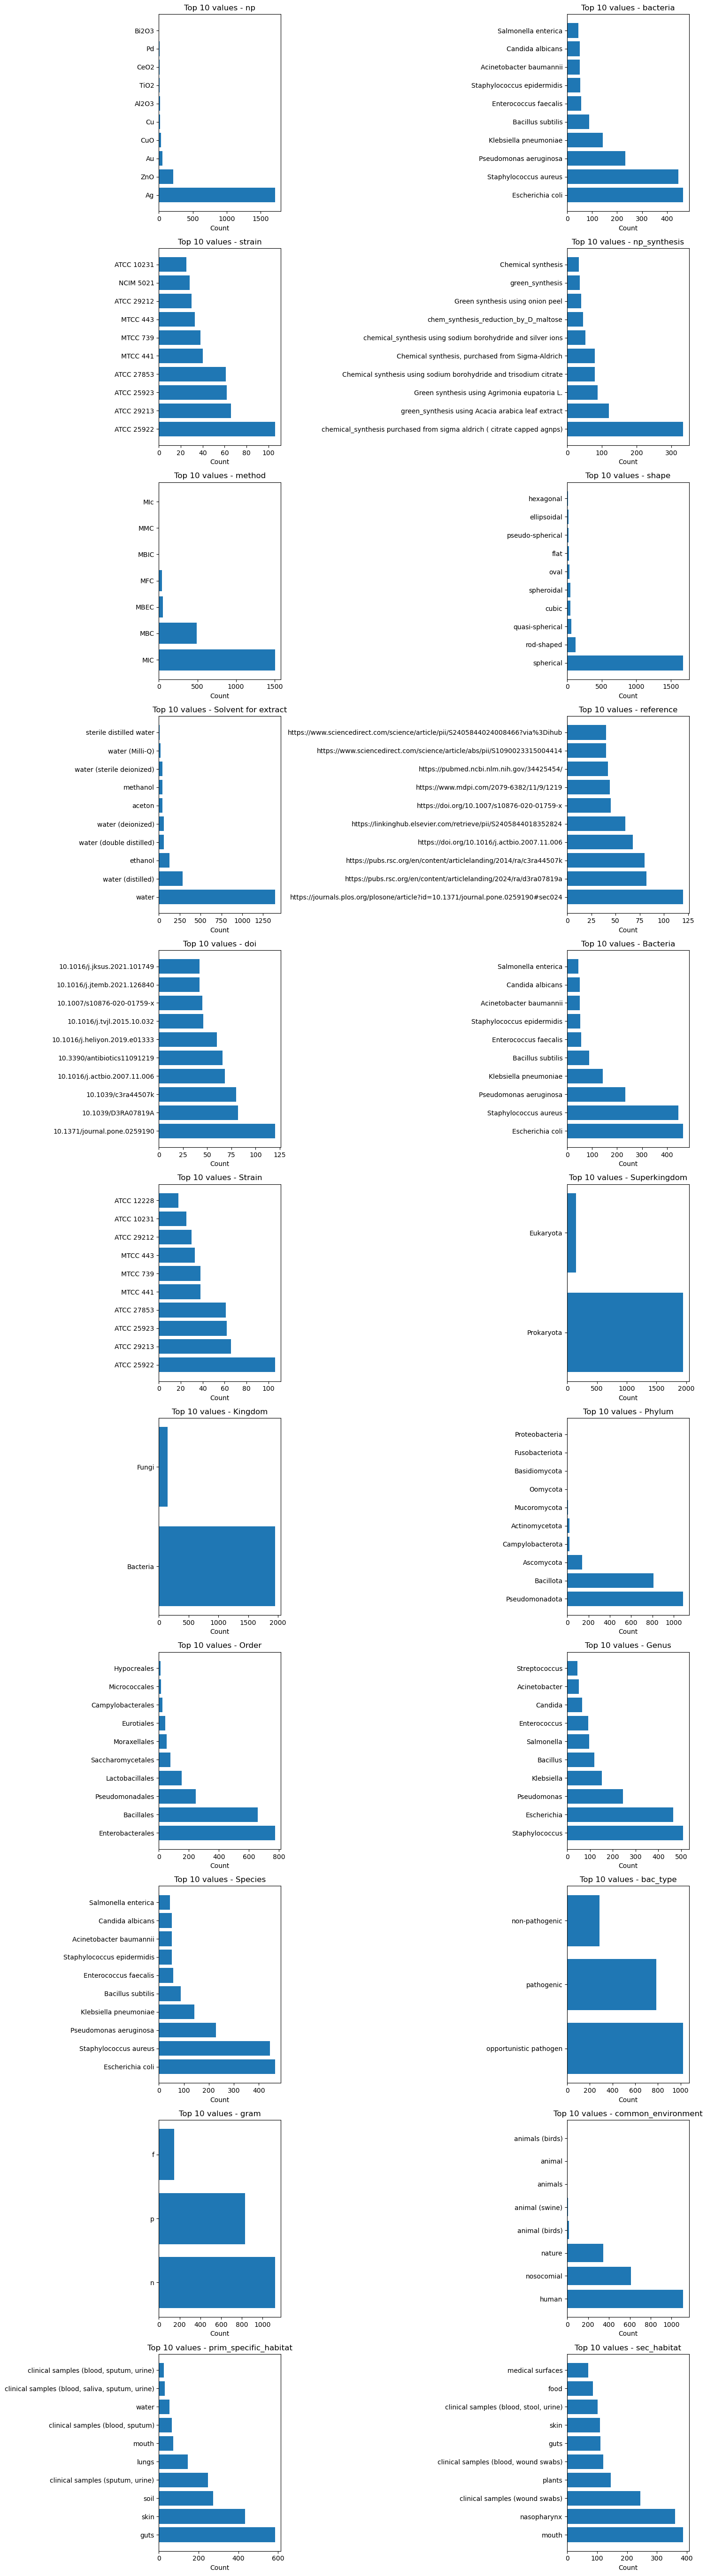


🥧 Pie Charts for Suitable Columns


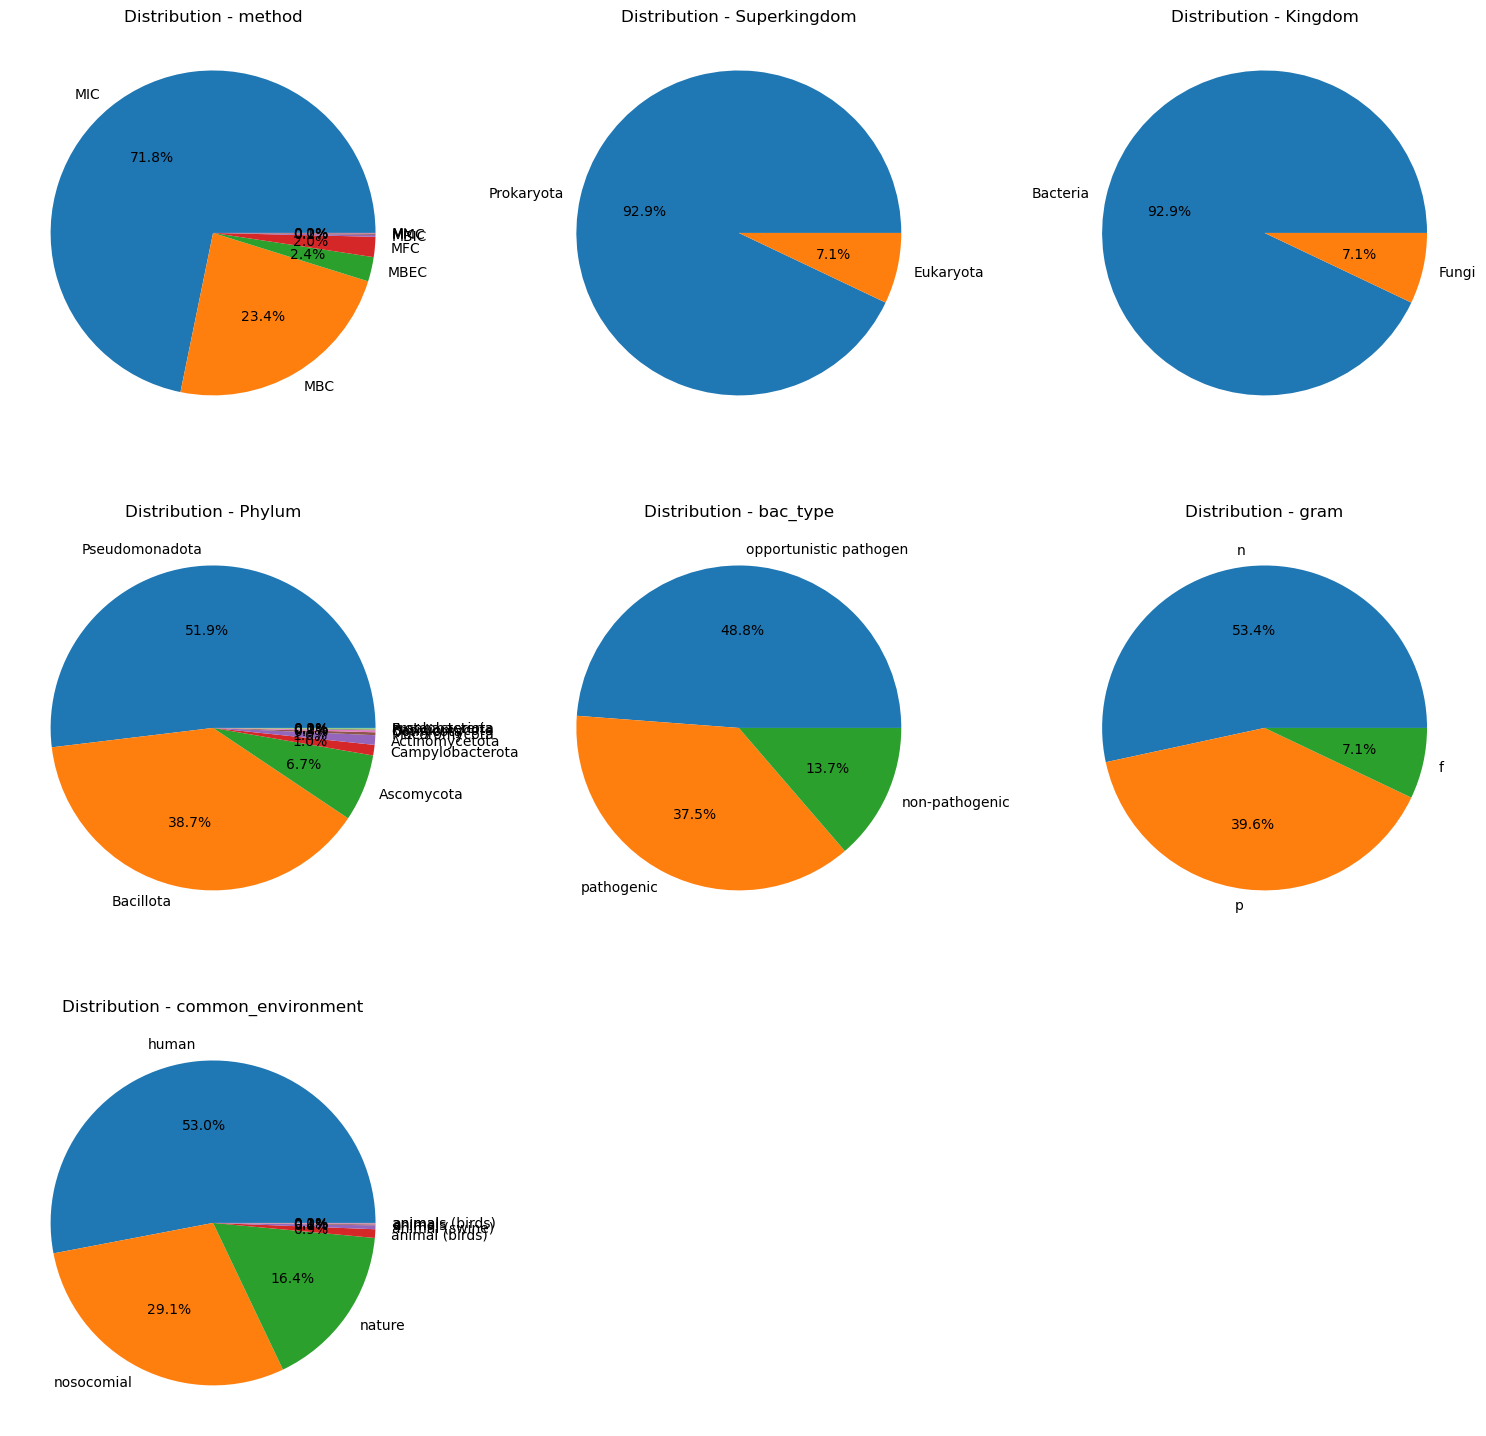


✅ Analysis complete!


In [14]:
analyze_dataframe(MIC_df, numerical_threshold=3)

🔍 Starting Data Analysis

Numerical columns: ['Unnamed: 0', 'coating', 'mdr', 'MIC_NP (µg/mL)', 'np_size_min (nm)', 'np_size_max (nm)', 'np_size_avg (nm)', 'time_set (hours)', 'Temperature for extract, C', 'Duration preparing extract, min', 'min_Incub_period, h', 'avg_Incub_period, h', 'max_Incub_period, h', 'growth_temp, C ', 'biosafety_level']
Categorical columns: ['np', 'bacteria', 'strain', 'np_synthesis', 'method', 'shape', 'Solvent for extract', 'reference', 'doi', 'Bacteria', 'Strain', 'Superkingdom', 'Kingdom', 'Phylum', 'Order', 'Genus', 'Species', 'bac_type', 'gram', 'common_environment', 'prim_specific_habitat', 'sec_habitat']

📊 Outlier Analysis (IQR Method)
=== Outlier Detection Report (IQR Method) ===

Column: Unnamed: 0
  Outlier count: 0
  Outlier percentage: 0.00%
  Lower bound: -1763.50
  Upper bound: 4846.50
  Outlier values: []
--------------------------------------------------
Column: coating
  Outlier count: 433
  Outlier percentage: 20.64%
  Lower bound: 0.00
  U

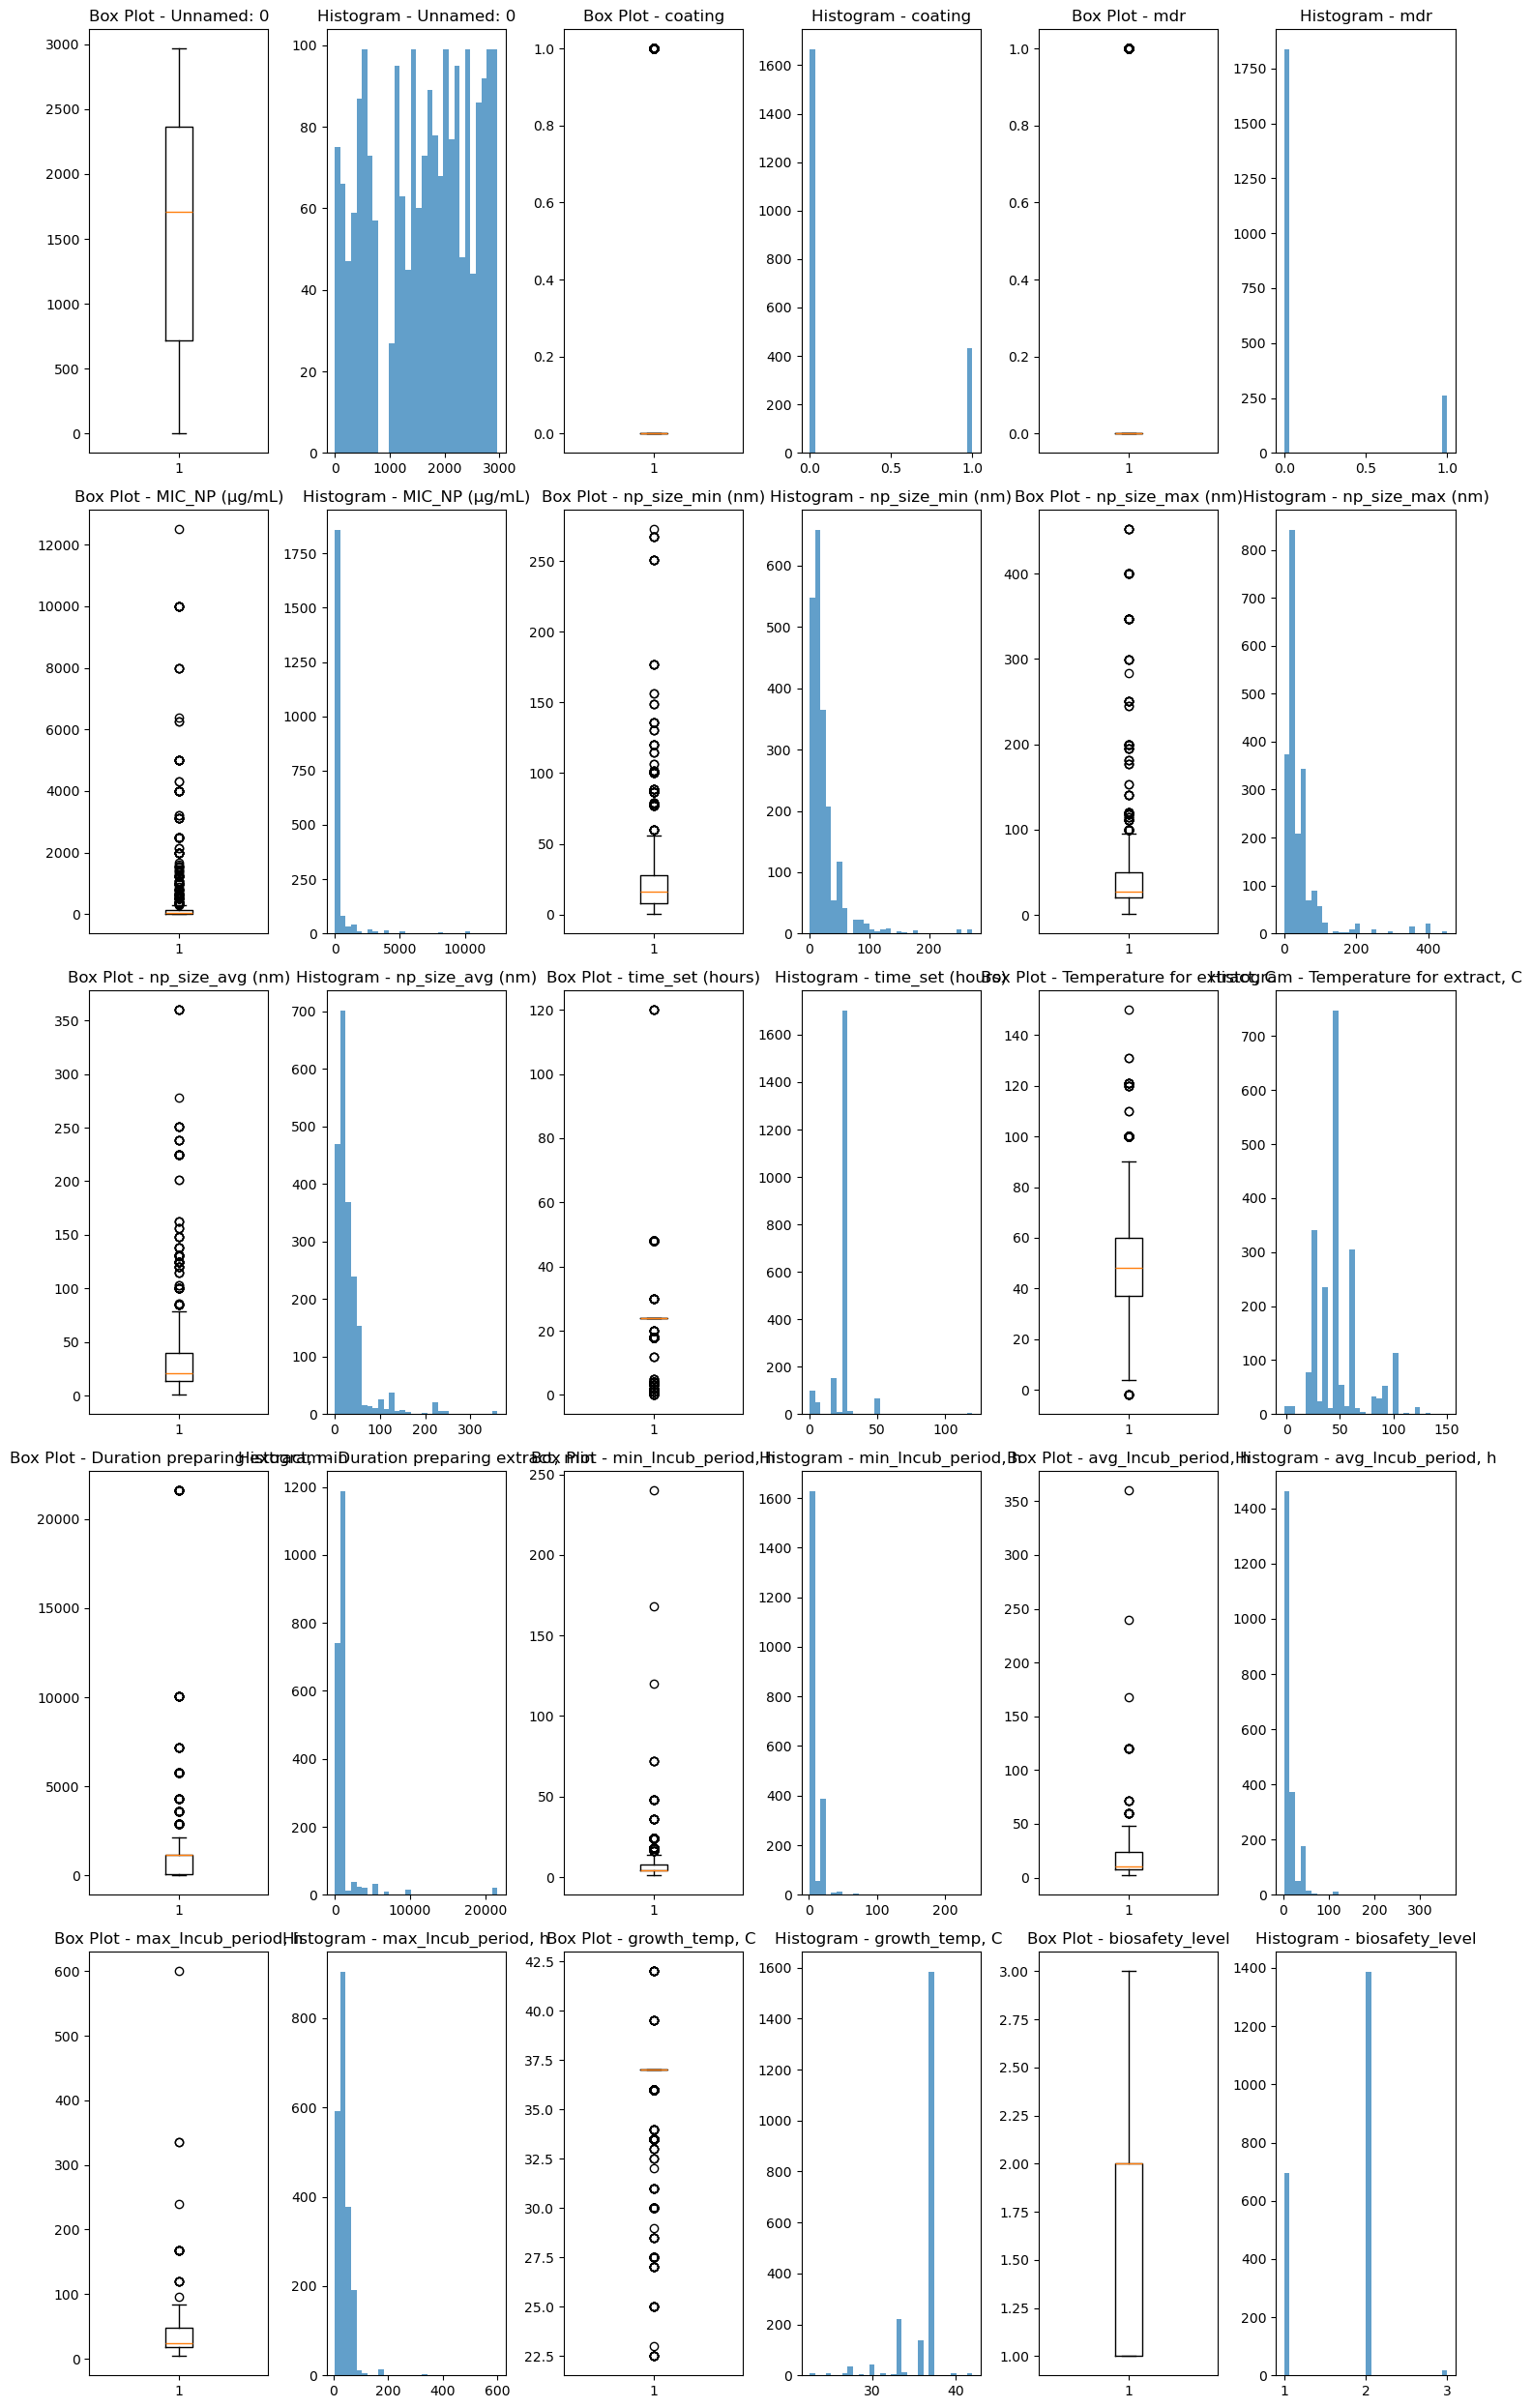


🎯 Categorical Distribution Analysis


NameError: name 'analyze_categorical_distribution' is not defined

In [12]:
analyze_dataframe(MIC_df, numerical_threshold=3)

In [16]:
def analyze_categorical_distribution(df, categorical_columns=None, top_n=10):
    """
    Analyze distribution of categorical columns
    """
    if categorical_columns is None:
        categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

    distribution_report = {}

    for col in categorical_columns:
        if col in df.columns:
            value_counts = df[col].value_counts()
            value_percentage = df[col].value_counts(normalize=True) * 100

            distribution_report[col] = {
                'unique_values': len(value_counts),
                'missing_values': df[col].isnull().sum(),
                'missing_percentage': (df[col].isnull().sum() / len(df)) * 100,
                'top_values': value_counts.head(top_n).to_dict(),
                'value_percentage': value_percentage.head(top_n).to_dict()
            }

    return distribution_report

def visualize_categorical_distribution(df, categorical_columns=None, top_n=10):
    """
    Create visualizations for categorical distribution
    """
    if categorical_columns is None:
        categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

    n_cols = min(2, len(categorical_columns))
    n_rows = (len(categorical_columns) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

    if len(categorical_columns) == 1:
        axes = np.array([axes])

    axes = axes.ravel()

    for i, col in enumerate(categorical_columns):
        if i < len(axes):
            top_values = df[col].value_counts().head(top_n)
            axes[i].barh(range(len(top_values)), top_values.values)
            axes[i].set_yticks(range(len(top_values)))
            axes[i].set_yticklabels(top_values.index)
            axes[i].set_title(f'Top {top_n} values - {col}')
            axes[i].set_xlabel('Count')

    # Hide empty subplots
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

def print_categorical_report(distribution_report):
    """
    Print a formatted categorical distribution report
    """
    print("=== Categorical Distribution Report ===\n")

    for col, stats in distribution_report.items():
        print(f"Column: {col}")
        print(f"  Unique values: {stats['unique_values']}")
        print(f"  Missing values: {stats['missing_values']} ({stats['missing_percentage']:.2f}%)")
        print("  Top values:")
        for value, count in stats['top_values'].items():
            percentage = stats['value_percentage'].get(value, 0)
            print(f"    {value}: {count} ({percentage:.2f}%)")
        print("-" * 50)

def create_pie_charts(df, categorical_columns=None, top_n=5):
    """
    Create pie charts for categorical columns (for columns with reasonable number of categories)
    """
    if categorical_columns is None:
        categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

    # Filter columns with reasonable number of categories for pie charts
    suitable_columns = [col for col in categorical_columns
                       if df[col].nunique() <= 10 and df[col].nunique() > 1]

    if not suitable_columns:
        print("No suitable columns for pie charts (should have 2-10 unique values)")
        return

    n_cols = min(3, len(suitable_columns))
    n_rows = (len(suitable_columns) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

    if len(suitable_columns) == 1:
        axes = np.array([axes])

    axes = axes.ravel()

    for i, col in enumerate(suitable_columns):
        if i < len(axes):
            value_counts = df[col].value_counts()
            axes[i].pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%')
            axes[i].set_title(f'Distribution - {col}')

    # Hide empty subplots
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

In [8]:
MIC_df

,Unnamed: 0,np,coating,bacteria,mdr,strain,np_synthesis,method,MIC_NP (µg/mL),np_size_min (nm),...,bac_type,gram,"min_Incub_period, h","avg_Incub_period, h","max_Incub_period, h","growth_temp, C",biosafety_level,common_environment,prim_specific_habitat,sec_habitat
0,0,Ag,0,Bacillus subtilis,0,MTCC 441,chemical_synthesis using sodium borohydride an...,MIC,40.000,2.26,...,non-pathogenic,p,6.0,12,18,33.5,1,nature,soil,plants
1,1,Ag,0,Bacillus subtilis,0,MTCC 441,chemical_synthesis using sodium borohydride an...,MBC,60.000,2.26,...,non-pathogenic,p,6.0,12,18,33.5,1,nature,soil,plants
2,2,Ag,0,Escherichia coli,0,MTCC 443,chemical_synthesis using sodium borohydride an...,MIC,40.000,2.26,...,pathogenic,n,6.0,12,18,37.0,1,human,guts,"clinical samples (blood, stool, urine)"
3,3,Ag,0,Escherichia coli,0,MTCC 739,chemical_synthesis using sodium borohydride an...,MIC,180.000,2.26,...,pathogenic,n,6.0,12,24,37.0,1,human,guts,"clinical samples (blood, stool, urine)"
4,4,Ag,0,Escherichia coli,0,MTCC 1302,chemical_synthesis using sodium borohydride an...,MIC,120.000,2.26,...,opportunistic pathogen,n,1.5,4,24,37.0,1,human,guts,mouth
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2093,2963,Ag,0,Escherichia coli,0,NaN,Green synthesis using Acacia cyanophylla,MIC,3.125,86.98,...,opportunistic pathogen,n,1.5,4,24,37.0,1,human,guts,mouth
2094,2964,Ag,0,Escherichia coli,0,NaN,Green synthesis using Acacia cyanophylla,MIC,6.250,86.98,...,opportunistic pathogen,n,1.5,4,24,37.0,1,human,guts,mouth
2095,2965,Ag,0,Escherichia coli,0,NaN,Green synthesis using Acacia cyanophylla,MIC,6.250,86.98,...,opportunistic pathogen,n,1.5,4,24,37.0,1,human,guts,mouth
2096,2966,Ag,0,Escherichia coli,0,NaN,Green synthesis using Acacia cyanophylla,MIC,6.250,86.98,...,opportunistic pathogen,n,1.5,4,24,37.0,1,human,guts,mouth
